# Análisis exploratorio de los datos estructurados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#### Carga de datos

In [ ]:
df_agri = pd.read_csv('datos/produccion_agricola.csv')
df_gana = pd.read_csv('datos/produccion_ganadera.csv')
df_precios = pd.read_csv('datos/precios_mercado_limpios.csv')
df_img = pd.read_csv('datos/imagenes_metadata_limpias.csv')

In [ ]:
df_agri.head()

,pais,codigo_iso,region,cultivo,anio,superficie_hectareas,rendimiento_ton_ha,produccion_ton,fertilizantes_kg_ha,agua_riego_m3_ha,tendencia_5_anios
0,Argentina,ARG,América del Sur,Soja,2011,4703643,2.22,10465461,105,4811,0.000536
1,Argentina,ARG,América del Sur,Maíz,2011,3371781,8.45,28485921,164,5557,0.030943
2,Argentina,ARG,América del Sur,Cebada,2011,1661577,2.77,4596917,105,6514,-0.039779
3,Argentina,ARG,América del Sur,Té,2011,188518,3.07,577886,236,8527,0.003623
4,Argentina,ARG,América del Sur,Algodón,2011,1638327,1.18,1929756,276,6925,0.007735


In [ ]:
df_gana.head()

,pais,anio,tipo_ganado,cabezas_ganado,produccion_carne_ton,produccion_leche_lt,emisiones_ch4_ton_co2eq,intensidad_emisiones,eficiencia_carne
0,Argentina,2011,bovino,18160590,1857394,2355425160,1121740,0.062,0.1023
1,Argentina,2011,porcino,13481224,1528896,0,1984357,0.147,0.1134
2,Argentina,2011,avicola,979196737,1290153,0,10160819,0.010,0.0013
3,Argentina,2011,ovino,13789178,477282,329191349,5061273,0.367,0.0346
4,Argentina,2011,caprino,2045715,345732,454558689,284966,0.139,0.1690


In [ ]:
df_precios.head()

,fecha,pais,producto,precio_usd_ton,volumen_operado_ton,tendencia_30_dias,mercado_principal,precio_min_mes,precio_max_mes
0,2021-01-01,Argentina,Carne_bovina,4299.14,127922,subiendo,UE,3844.74,4517.42
1,2021-01-01,Argentina,Arroz,330.04,73231,subiendo,Sudeste Asiático,310.10,359.86
2,2021-01-01,Argentina,Maíz,210.36,11666,bajando,Japón,200.56,238.83
3,2021-01-01,Brasil,Maíz,212.91,195579,subiendo,Oriente Medio,200.25,243.04
4,2021-01-01,Brasil,Leche,356.41,136137,subiendo,UE,348.39,390.03


In [ ]:
df_img.head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja


### Análisis agricola y satelite

#### 1. Fertilizantes vs Rendimiento

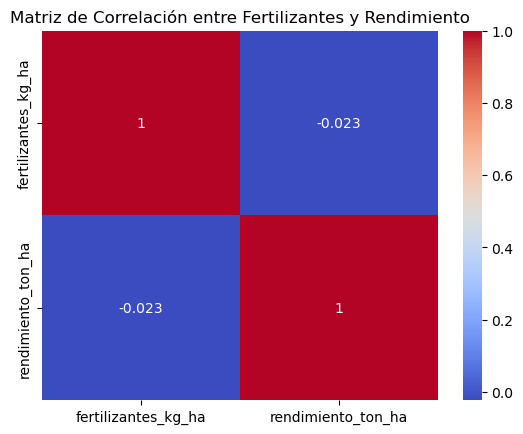

In [ ]:
#Matriz de correlación para kg de fertilizante y rendimiento
correlation_matrix = df_agri[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Fertilizantes y Rendimiento')
plt.show()

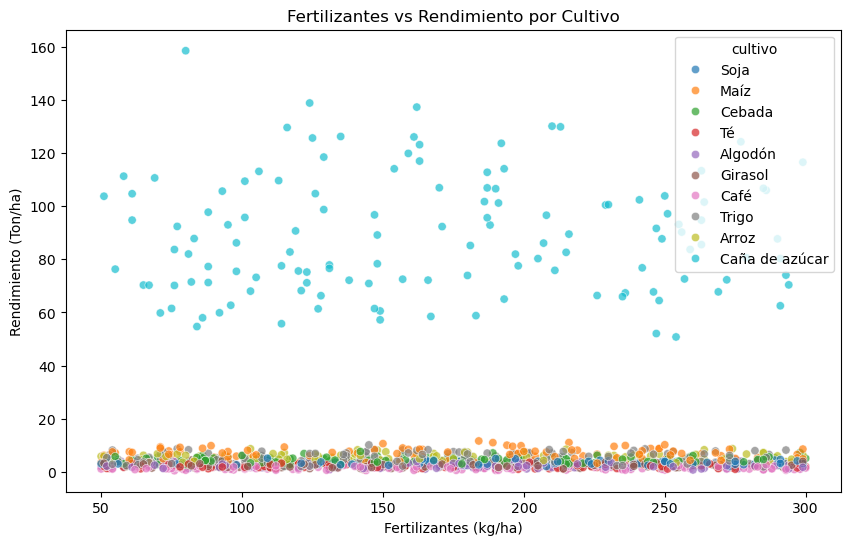

In [ ]:
plt.figure(figsize=(10, 6)) 
sns.scatterplot(data=df_agri, x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', alpha=0.7)
plt.title('Fertilizantes vs Rendimiento por Cultivo')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (Ton/ha)')
plt.show()

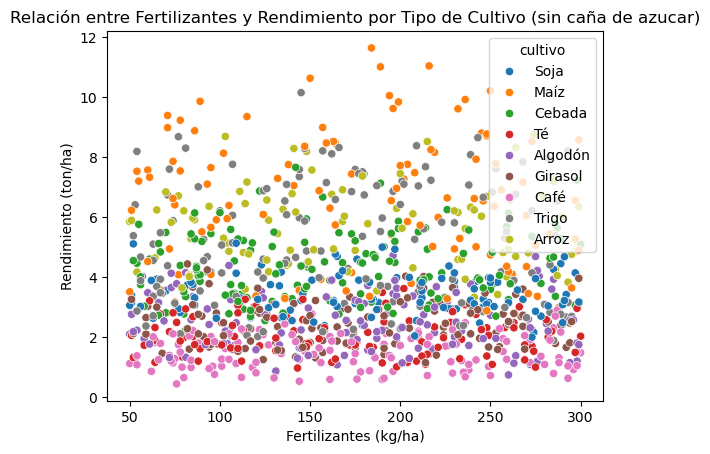

In [ ]:
#Grafico de dispersión para kg de fertilizante y rendimiento quitando el cultivo de caña de azucar
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
sns.scatterplot(x='fertilizantes_kg_ha', y='rendimiento_ton_ha', hue='cultivo', data=df_sin_cana)
plt.title('Relación entre Fertilizantes y Rendimiento por Tipo de Cultivo (sin caña de azucar)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.show()

#### 2. Superficie vs producción

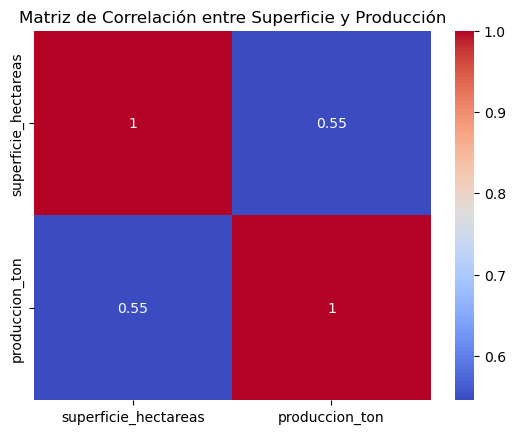

In [ ]:
#Matriz de correlación para superficie y produccion
correlation_matrix = df_agri[['superficie_hectareas', 'produccion_ton']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Superficie y Producción')
plt.show()

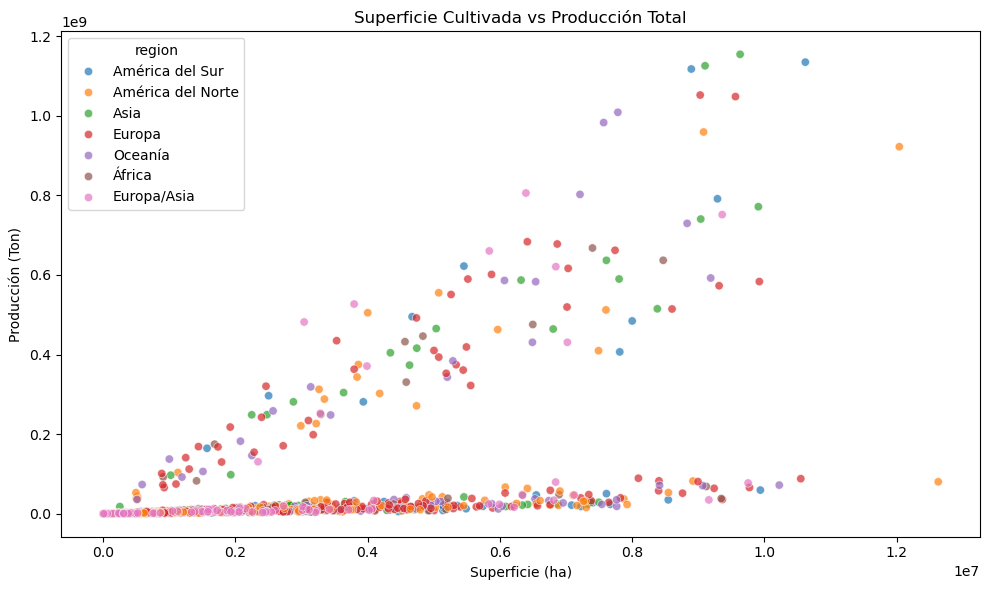

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agri, x='superficie_hectareas', y='produccion_ton', hue='region', alpha=0.7)
plt.title('Superficie Cultivada vs Producción Total')
plt.xlabel('Superficie (ha)')
plt.ylabel('Producción (Ton)')
plt.tight_layout()
plt.show()

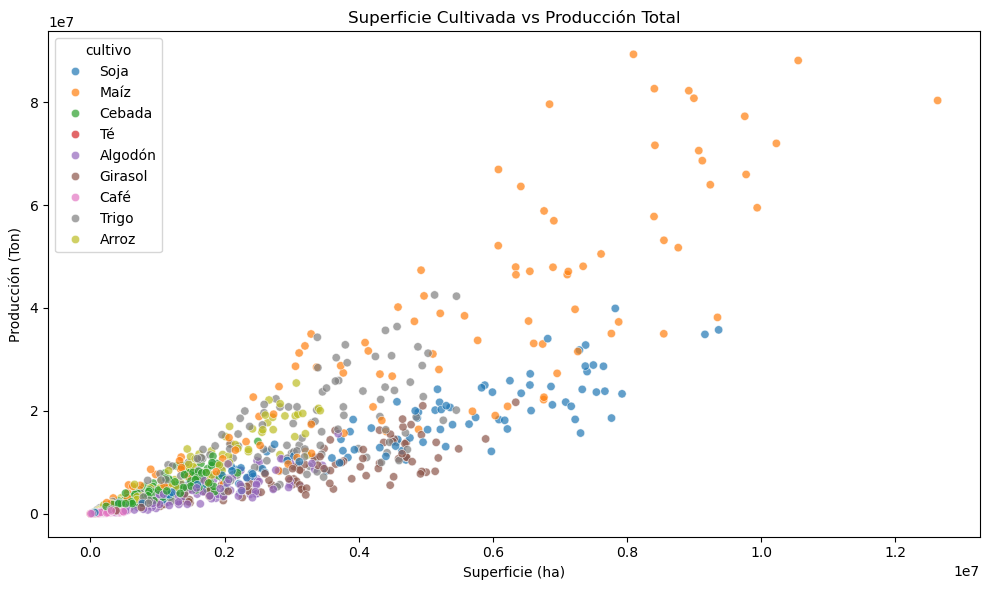

In [ ]:
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sin_cana, x='superficie_hectareas', y='produccion_ton', hue='cultivo', alpha=0.7)
plt.title('Superficie Cultivada vs Producción Total')
plt.xlabel('Superficie (ha)')
plt.ylabel('Producción (Ton)')
plt.tight_layout()
plt.show()

#### 3. Relación agua vs rendimiento

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_28636\1515975919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


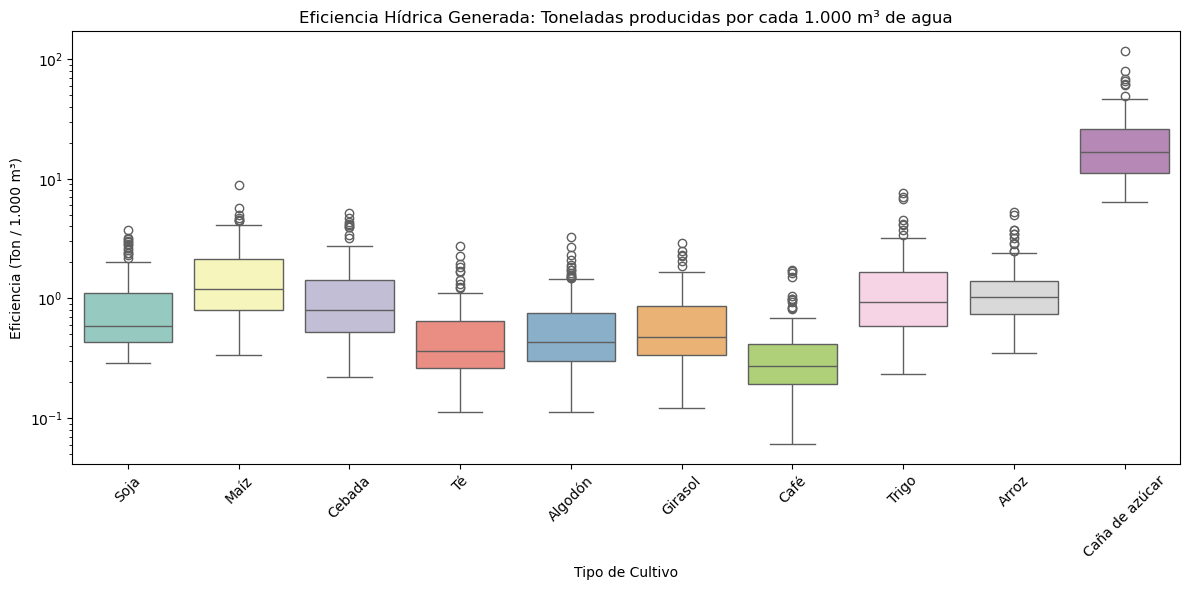

In [ ]:
# Calculamos: ¿Cuántas toneladas produce con 1000 m3 de agua?
df_agri['eficiencia_hidrica'] = df_agri['rendimiento_ton_ha'] / (df_agri['agua_riego_m3_ha'] / 1000)

plt.figure(figsize=(12, 6))
# Usamos un boxplot para ver la distribución completa y la mediana por cultivo
sns.boxplot(
    data=df_agri, 
    x='cultivo', 
    y='eficiencia_hidrica', 
    palette='Set3'
)
plt.title('Eficiencia Hídrica Generada: Toneladas producidas por cada 1.000 m³ de agua')
plt.ylabel('Eficiencia (Ton / 1.000 m³)')
plt.xlabel('Tipo de Cultivo')
plt.xticks(rotation=45)
# Escala logarítmica si hay cultivos con eficiencias extremadamente altas/bajas
plt.yscale('log') 
plt.tight_layout()
plt.show()

#### 4. Relaciones satelitales

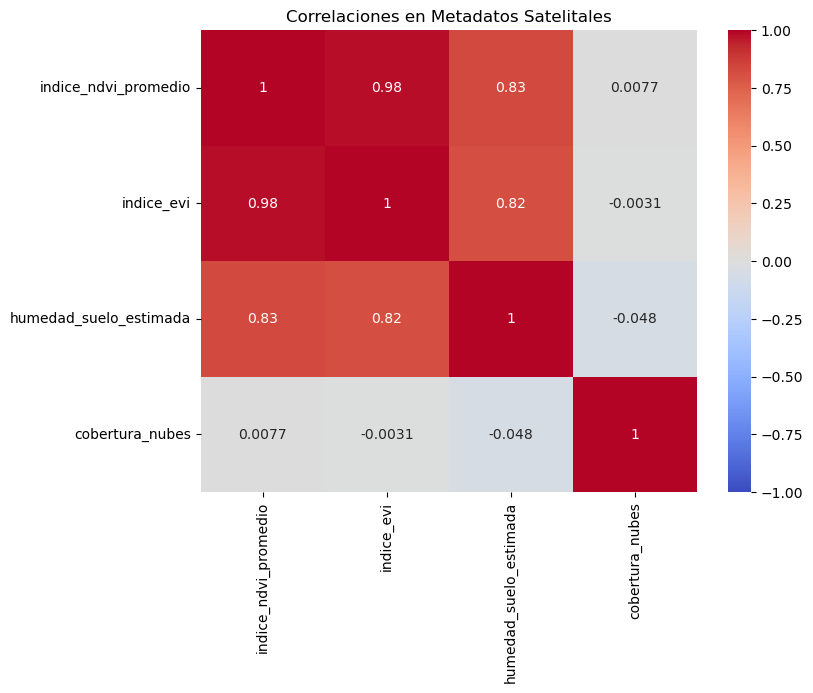

In [ ]:
# Matriz Satelital
plt.figure(figsize=(8, 6))
cols_img = ['indice_ndvi_promedio', 'indice_evi', 'humedad_suelo_estimada', 'cobertura_nubes']
sns.heatmap(df_img[cols_img].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlaciones en Metadatos Satelitales')
plt.show()

### Análisis temporales 

#### 1. Tendencia de producción global por cultivo y pais

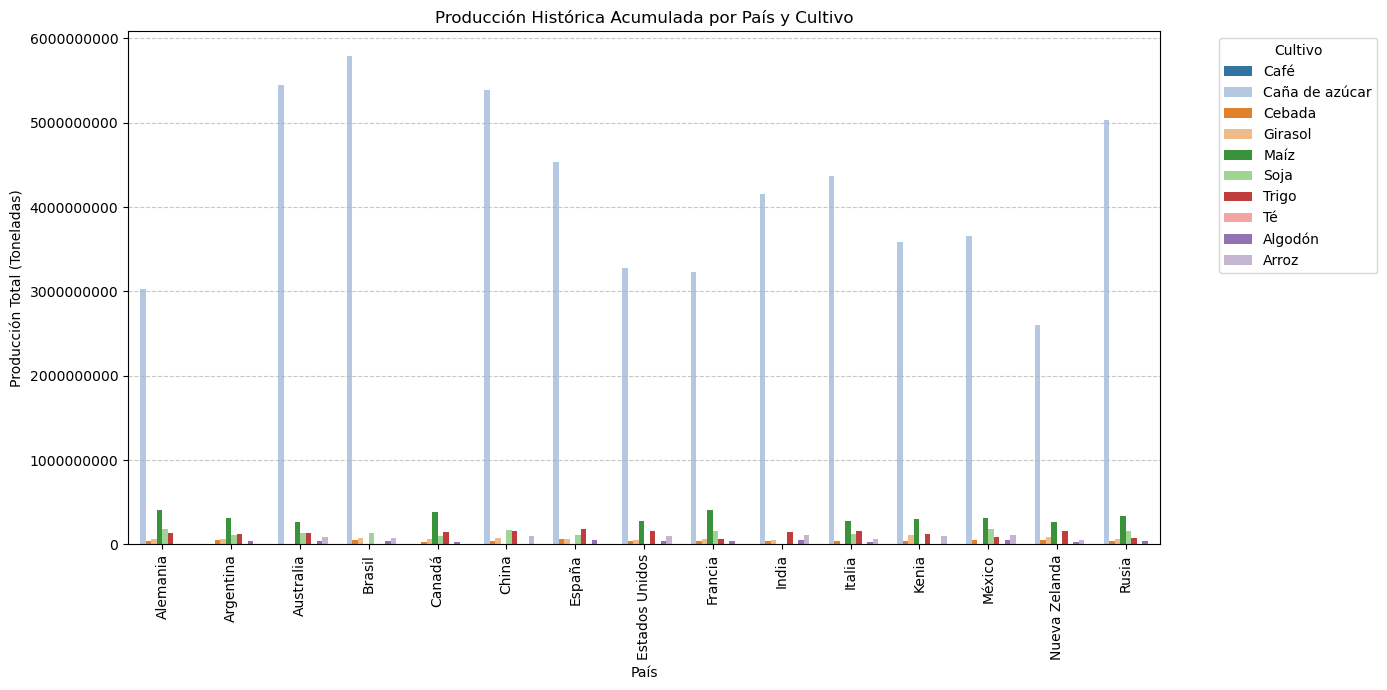

In [ ]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agri.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

# Identificar producción total
paises = df_agri.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo[prod_pais_cultivo['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

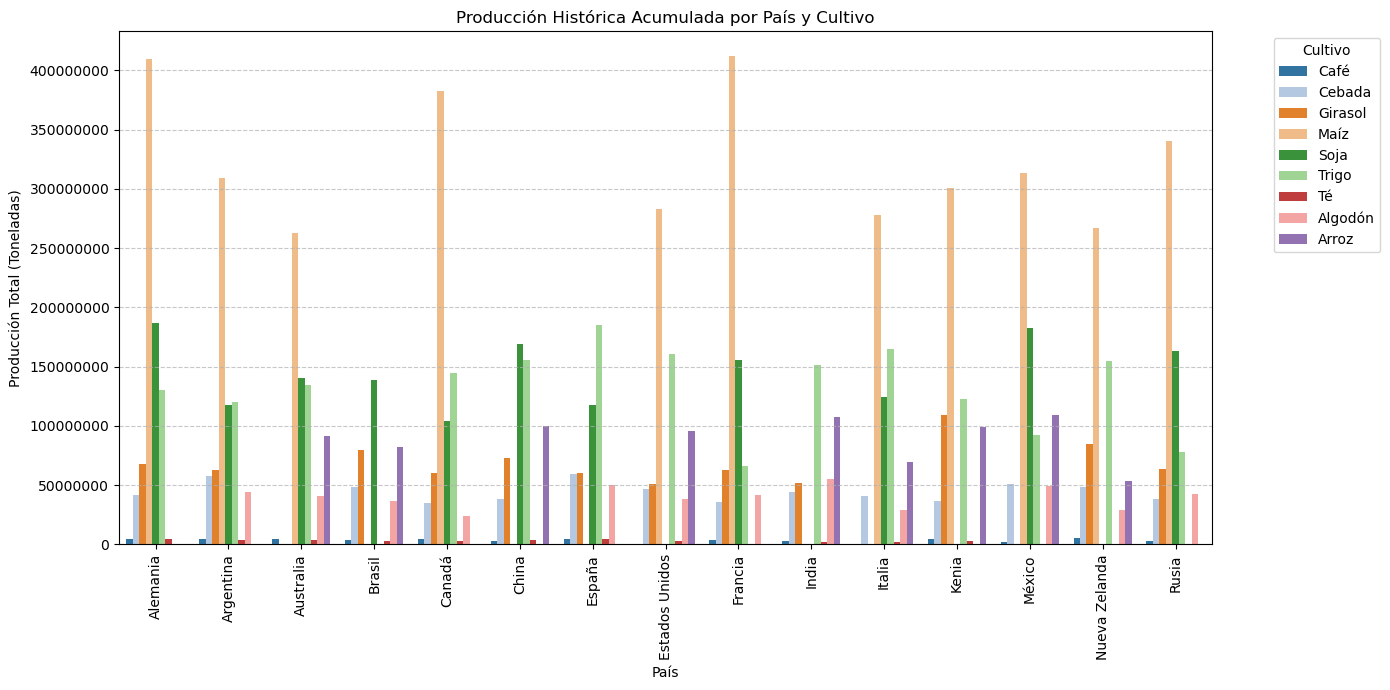

In [ ]:
# Agrupar la producción sumando toneladas por País y Cultivo (sin Año)
prod_pais_cultivo = df_agri.groupby(['pais', 'cultivo'])['produccion_ton'].sum().reset_index()

prod_pais_cultivo_sin_cana = prod_pais_cultivo[prod_pais_cultivo['cultivo'] != 'Caña de azúcar']
# Identificar producción total
paises = df_agri.groupby('pais')['produccion_ton'].sum().index

# Filtrar el dataset agrupado solo para estos países
df_top = prod_pais_cultivo_sin_cana[prod_pais_cultivo_sin_cana['pais'].isin(paises)]

# Gráfico de barras agrupadas
plt.figure(figsize=(14, 7))
# Hacer que el valor de x sea vertical
plt.xticks(rotation=90)
sns.barplot(data=df_top, x='pais', y='produccion_ton', hue='cultivo', palette='tab20') 


plt.title('Producción Histórica Acumulada por País y Cultivo')
plt.xlabel('País')
plt.ylabel('Producción Total (Toneladas)')
plt.ticklabel_format(style='plain', axis='y') # Evitar notación científica
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

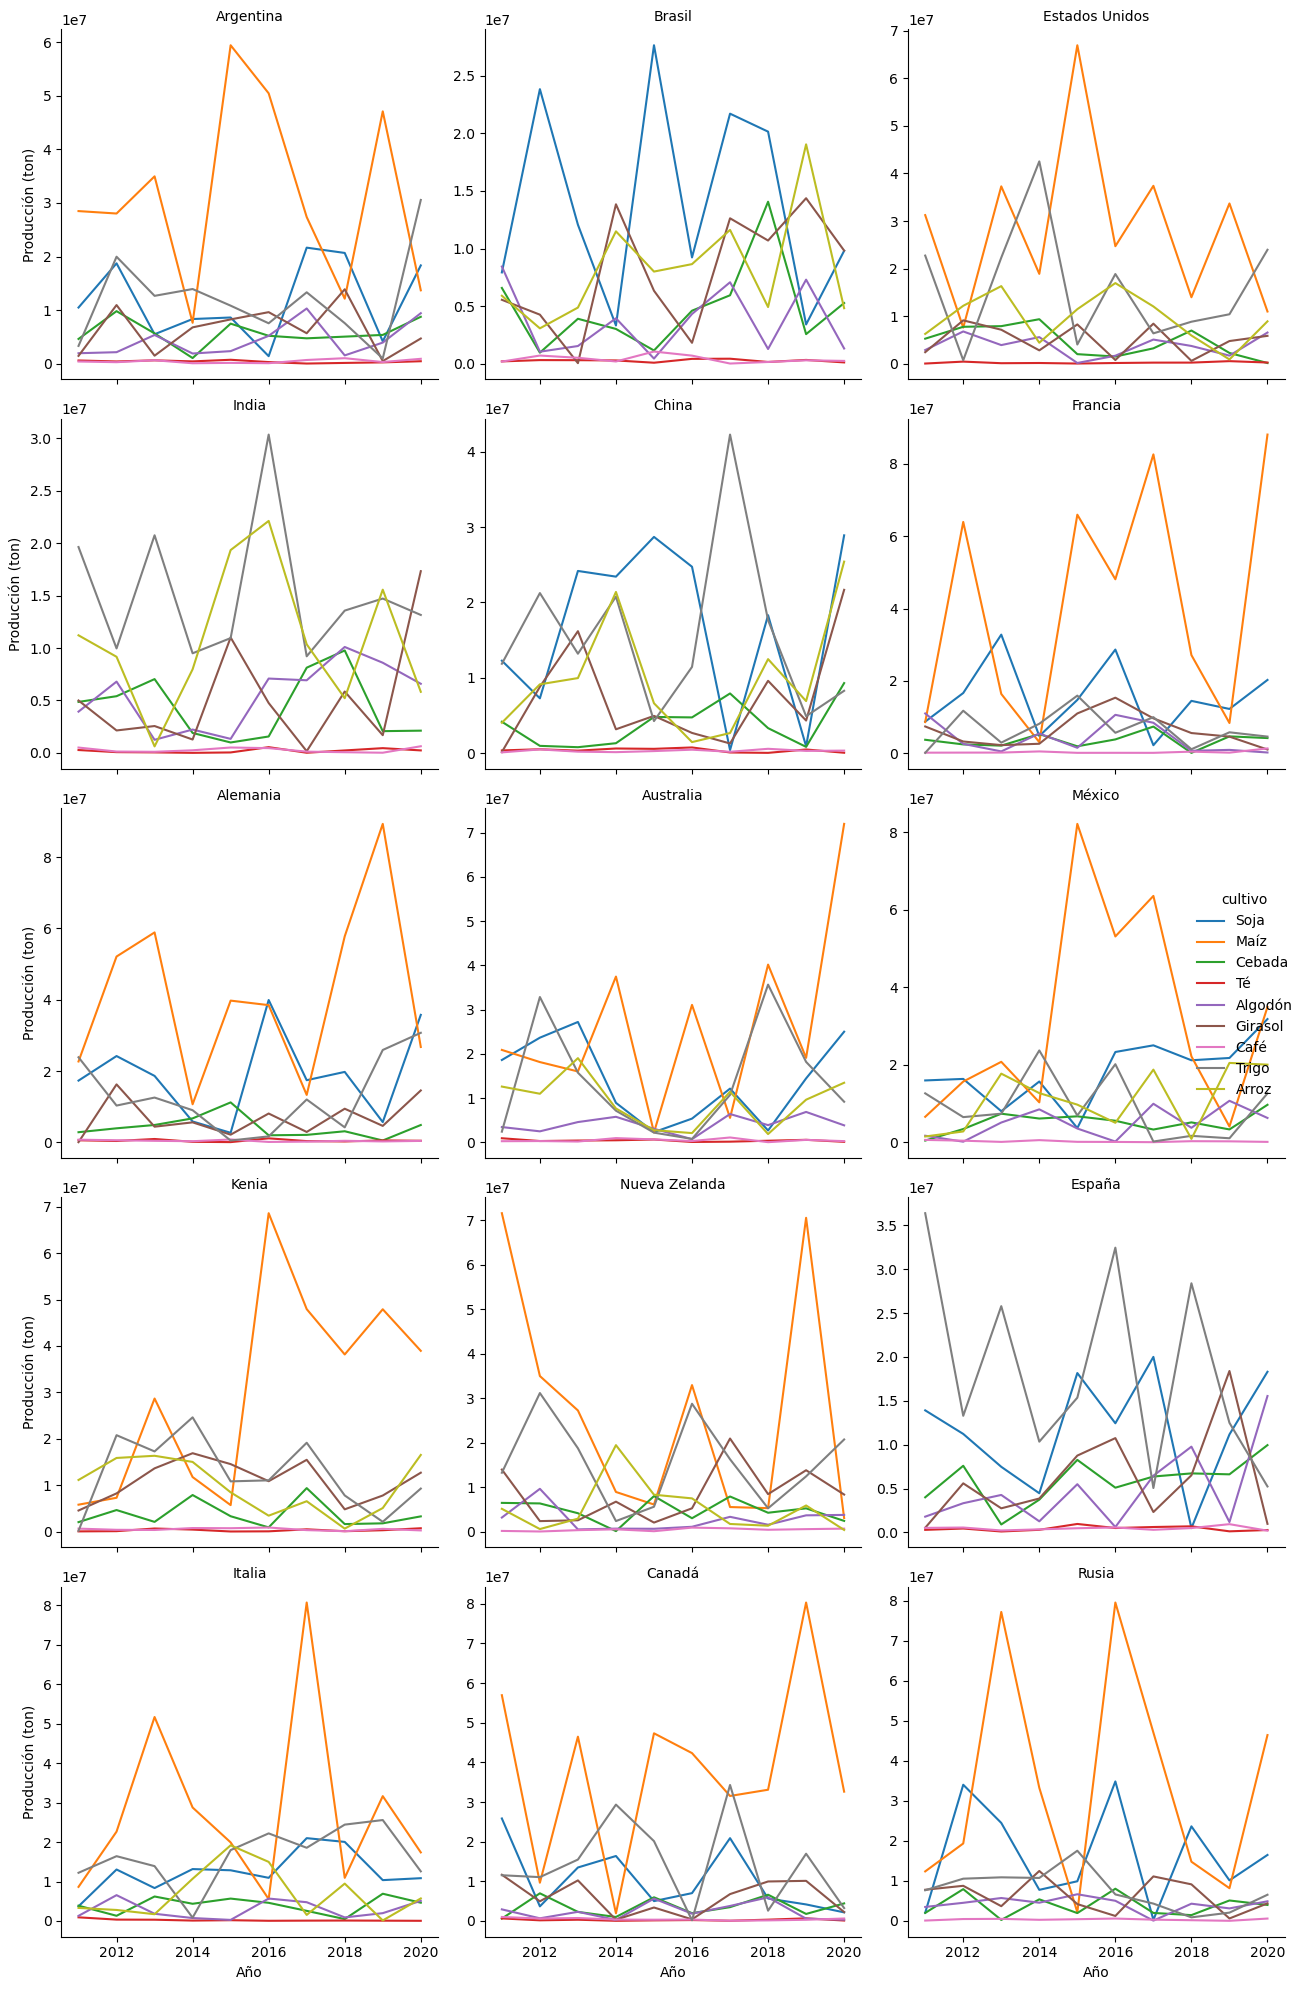

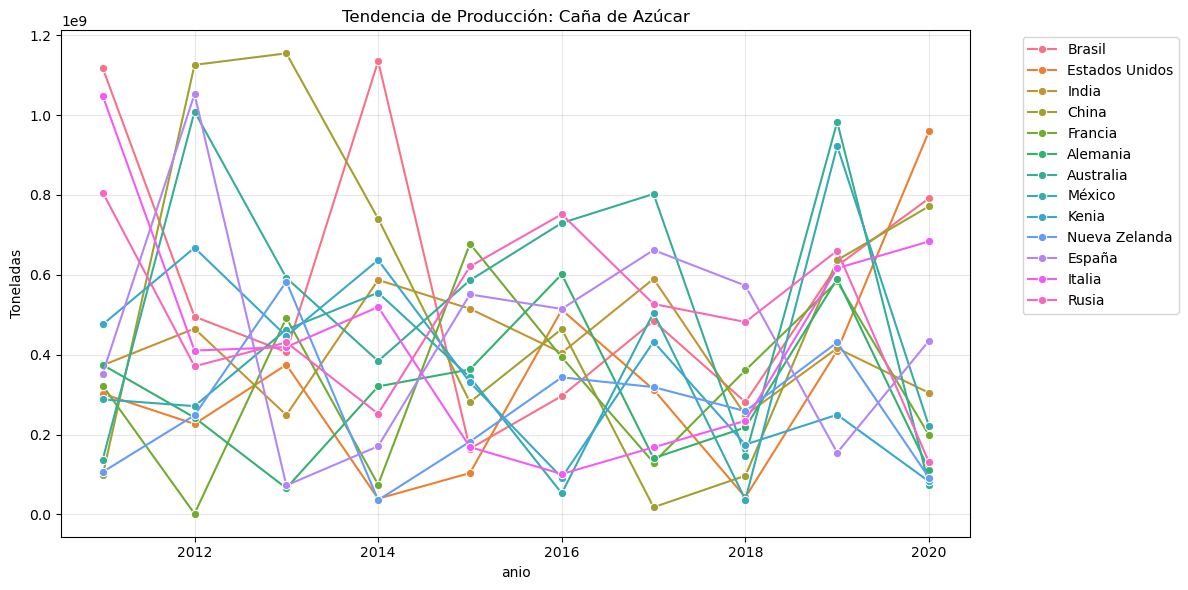

In [ ]:
# Gráfico para TODOS los países y cultivos (FacetGrid)
df_sin_cana = df_agri[df_agri['cultivo'] != 'Caña de azúcar']
g = sns.FacetGrid(df_sin_cana, col="pais", hue="cultivo", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "anio", "produccion_ton")
g.add_legend()
g.set_axis_labels("Año", "Producción (ton)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

# Gráfico específico para CAÑA DE AZÚCAR
df_cana = df_agri[df_agri['cultivo'] == 'Caña de azúcar']
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_cana, x='anio', y='produccion_ton', hue='pais', marker='o')
plt.title('Tendencia de Producción: Caña de Azúcar')
plt.ylabel('Toneladas')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Como se puede observar no existe una tendencia en la produccion, tan solo la produccion que se mantiene estable en el tiempo es el café y el té.

#### 2. Anomalías en series temporales

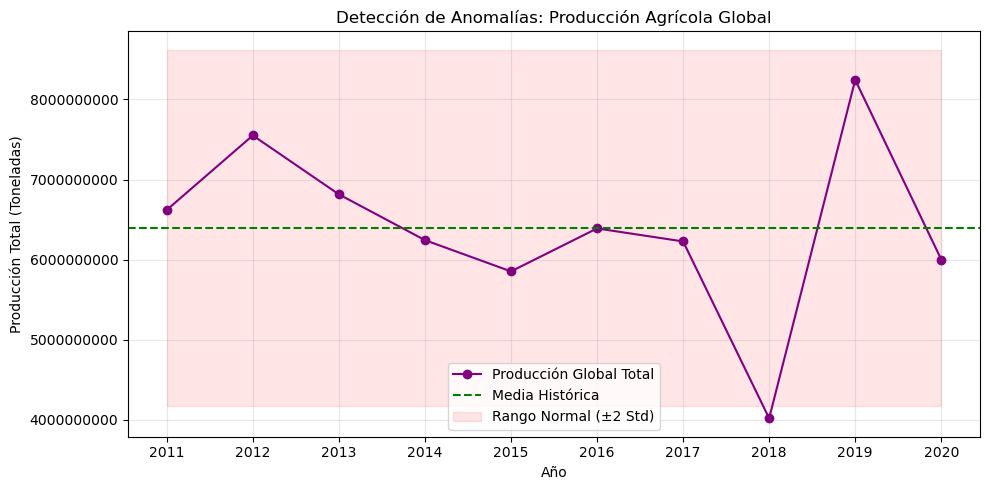

In [ ]:
# Agrupamos la producción global total por año
tendencia_global = df_agri.groupby('anio')['produccion_ton'].sum().reset_index()

media_global = tendencia_global['produccion_ton'].mean()
std_global = tendencia_global['produccion_ton'].std()

plt.figure(figsize=(10, 5))
plt.plot(tendencia_global['anio'], tendencia_global['produccion_ton'], marker='o', color='purple', label='Producción Global Total')
plt.axhline(media_global, color='green', linestyle='--', label='Media Histórica')
plt.fill_between(tendencia_global['anio'], media_global - 2*std_global, media_global + 2*std_global, color='red', alpha=0.1, label='Rango Normal (±2 Std)')
plt.title('Detección de Anomalías: Producción Agrícola Global')
plt.xlabel('Año')
plt.ylabel('Producción Total (Toneladas)')
plt.xticks(range(2011, 2021))
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



#### 3. Patrones estacionales

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_28636\2105625203.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=estacionalidad_global, x='mes', y='precio_usd_ton', palette='magma')


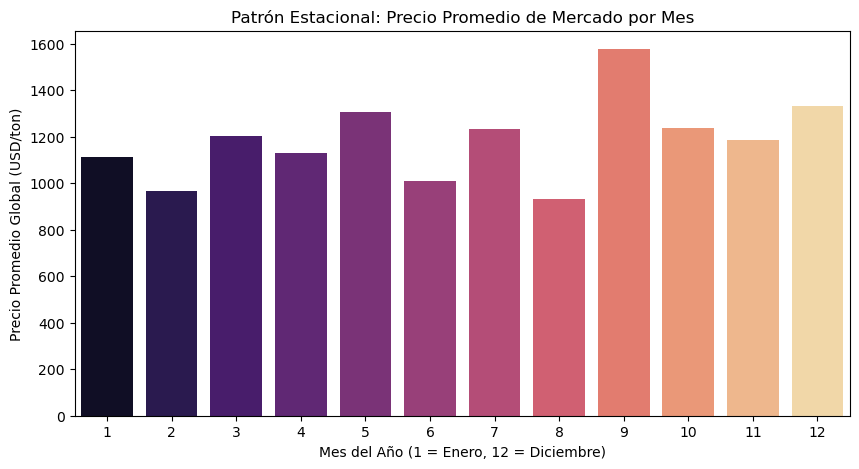

In [ ]:
# Cargar el dataset de precios
df_precios = pd.read_csv('datos/precios_mercado.csv')

# Transformar la columna fecha para extraer el "Mes"
df_precios['fecha'] = pd.to_datetime(df_precios['fecha'])
df_precios['mes'] = df_precios['fecha'].dt.month

# Agrupar el precio promedio global por mes
estacionalidad_global = df_precios.groupby('mes')['precio_usd_ton'].mean().reset_index()

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(data=estacionalidad_global, x='mes', y='precio_usd_ton', palette='magma')

plt.title('Patrón Estacional: Precio Promedio de Mercado por Mes')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Precio Promedio Global (USD/ton)')
plt.show()

### Geoespacial

#### 1. Clusterización de países por patrones productivos

c:\Users\Ccp0897\anaconda3\envs\piaentorno\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


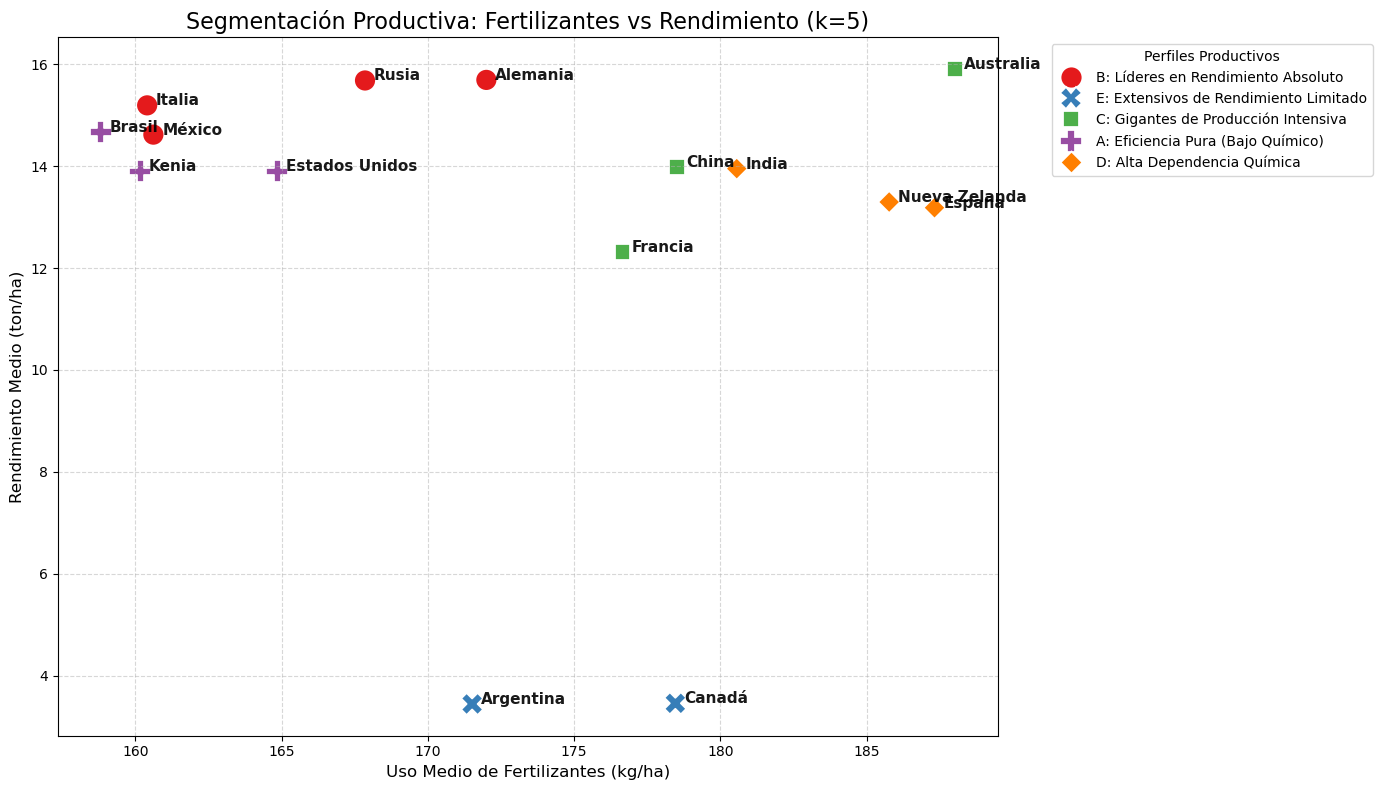

In [ ]:
df_ag_pais = df_agri.groupby('pais').agg({
    'produccion_ton': 'mean',
    'rendimiento_ton_ha': 'mean',
    'fertilizantes_kg_ha': 'mean',
    'superficie_hectareas': 'mean'
}).reset_index()

# 3. Machine Learning: Preparar y Escalar (K=5)
features = ['produccion_ton', 'rendimiento_ton_ha', 'fertilizantes_kg_ha', 'superficie_hectareas']
X_scaled = StandardScaler().fit_transform(df_ag_pais[features])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_ag_pais['cluster_num'] = kmeans.fit_predict(X_scaled)

# 4. Asignar nombres de negocio a los clústeres (Basados en nuestro análisis)
nombres_clusters = {
    3: 'A: Eficiencia Pura (Bajo Químico)',
    4: 'B: Líderes en Rendimiento Absoluto',
    0: 'C: Gigantes de Producción Intensiva',
    1: 'D: Alta Dependencia Química',
    2: 'E: Extensivos de Rendimiento Limitado'
}
df_ag_pais['Perfil_Productivo'] = df_ag_pais['cluster_num'].map(nombres_clusters)

# 5. Visualización
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_ag_pais, 
    x='fertilizantes_kg_ha', 
    y='rendimiento_ton_ha', 
    hue='Perfil_Productivo', 
    palette='Set1', 
    s=250, 
    style='Perfil_Productivo'
)

# Añadir etiquetas de países
for i in range(df_ag_pais.shape[0]):
    plt.text(df_ag_pais['fertilizantes_kg_ha'][i] + 0.3, # Desplazamiento X
             df_ag_pais['rendimiento_ton_ha'][i], 
             df_ag_pais['pais'][i], fontsize=11, alpha=0.9, fontweight='bold')

plt.title('Segmentación Productiva: Fertilizantes vs Rendimiento (k=5)', fontsize=16)
plt.xlabel('Uso Medio de Fertilizantes (kg/ha)', fontsize=12)
plt.ylabel('Rendimiento Medio (ton/ha)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Forzar leyenda fuera del gráfico
plt.legend(title="Perfiles Productivos", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

Al evaluar solo las técnicas de cultivo, el algoritmo ha detectado esto:

Clúster A: "Eficiencia Pura" (Brasil, EE.UU., Kenia): Logran muy buenos rendimientos usando la cantidad más baja de fertilizantes de todo el dataset.

Clúster B: "Líderes de Rendimiento" (Alemania, Italia, México, Rusia): Consiguen el rendimiento por hectárea más alto posible, con grandes extensiones de terreno y un uso moderado de químicos.

Clúster C: "Gigantes Intensivos" (Australia, China, Francia): Las mayores medias de producción total, pero a costa de usar dosis muy altas de fertilizantes.

Clúster D: "Dependencia Química" (España, India, Nueva Zelanda): Usan la mayor cantidad de fertilizantes de todo el mundo para mantener sus rendimientos a flote en terrenos más pequeños.

Clúster E: "Extensivos Limitados" (Argentina, Canadá): Rendimientos por hectárea muy bajos a pesar de usar grandes dosis de fertilizante.

#### 2. Comparación eficiencia productiva

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_28636\1835811393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


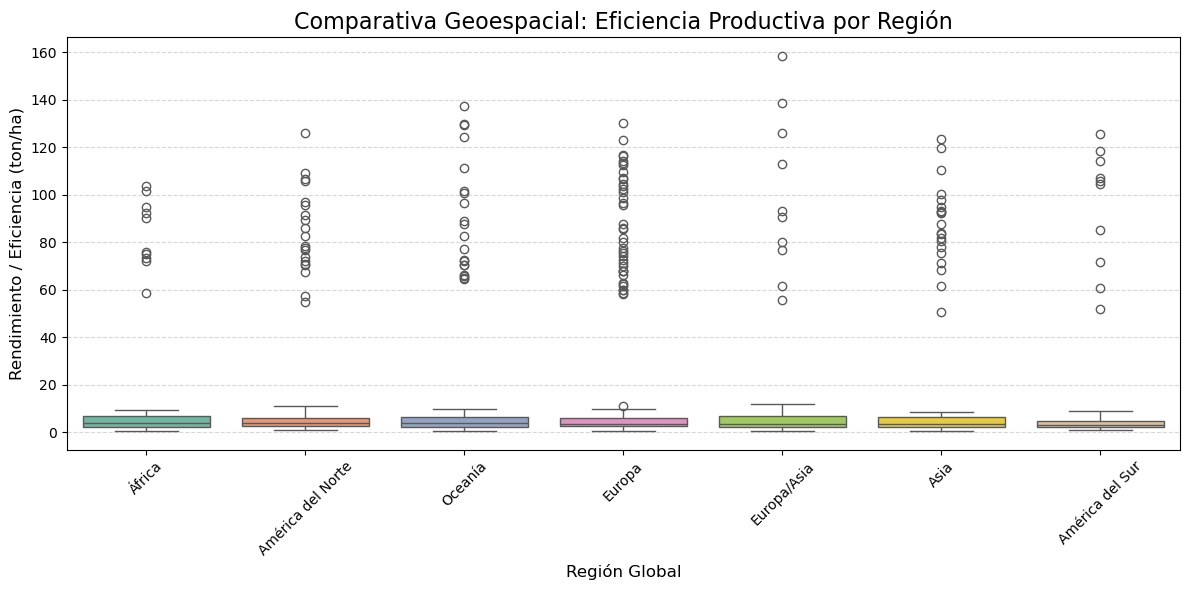

--- Mediana de Rendimiento por Región ---
region
África               3.970
América del Norte    3.675
Oceanía              3.625
Europa               3.540
Europa/Asia          3.425
Asia                 3.285
América del Sur      3.140
Name: rendimiento_ton_ha, dtype: float64


In [ ]:
# Calcular el orden: Ordenamos las regiones por su rendimiento mediano
orden_regiones = df_agri.groupby('region')['rendimiento_ton_ha'].median().sort_values(ascending=False).index

# Visualización: Diagrama de Cajas ordenado
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_agri, 
    x='region', 
    y='rendimiento_ton_ha', 
    order=orden_regiones, 
    palette='Set2'
)

plt.title('Comparativa Geoespacial: Eficiencia Productiva por Región', fontsize=16)
plt.xlabel('Región Global', fontsize=12)
plt.ylabel('Rendimiento / Eficiencia (ton/ha)', fontsize=12)
plt.xticks(rotation=45) # Rotamos los textos del eje X para que no se pisen
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Imprimimos los datos exactos por consola para ayudarte a redactar
print("--- Mediana de Rendimiento por Región ---")
print(df_agri.groupby('region')['rendimiento_ton_ha'].median().sort_values(ascending=False))

### Coste ambiental

#### 1. Producción vs Emisiones

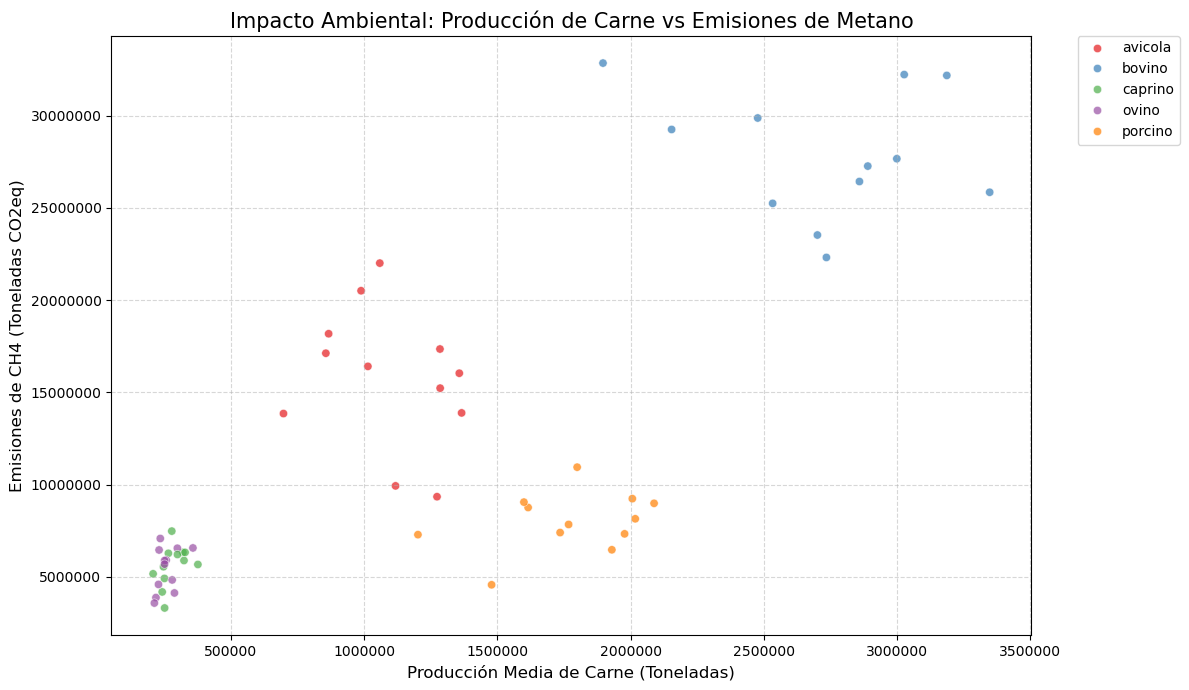

In [ ]:
# Agrupar los datos históricos (Promedio por país y tipo de ganado)
ganaderia_agrupada = df_gana.groupby(['pais', 'tipo_ganado']).agg({
    'produccion_carne_ton': 'mean',
    'emisiones_ch4_ton_co2eq': 'mean',
    'cabezas_ganado': 'mean'
}).reset_index()

# Visualización: Gráfico de dispersión (Burbujas)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=ganaderia_agrupada, 
    x='produccion_carne_ton', 
    y='emisiones_ch4_ton_co2eq', 
    hue='tipo_ganado', 
    alpha=0.7, 
    palette='Set1'
)

plt.title('Impacto Ambiental: Producción de Carne vs Emisiones de Metano', fontsize=15)
plt.xlabel('Producción Media de Carne (Toneladas)', fontsize=12)
plt.ylabel('Emisiones de CH4 (Toneladas CO2eq)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both') # Quitar notación científica
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar leyenda
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

#### 2. Eficiencia de emisiones

C:\Users\Ccp0897\AppData\Local\Temp\ipykernel_28636\2647455605.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_extremos, x='pais', y='intensidad_emisiones', palette=colores)


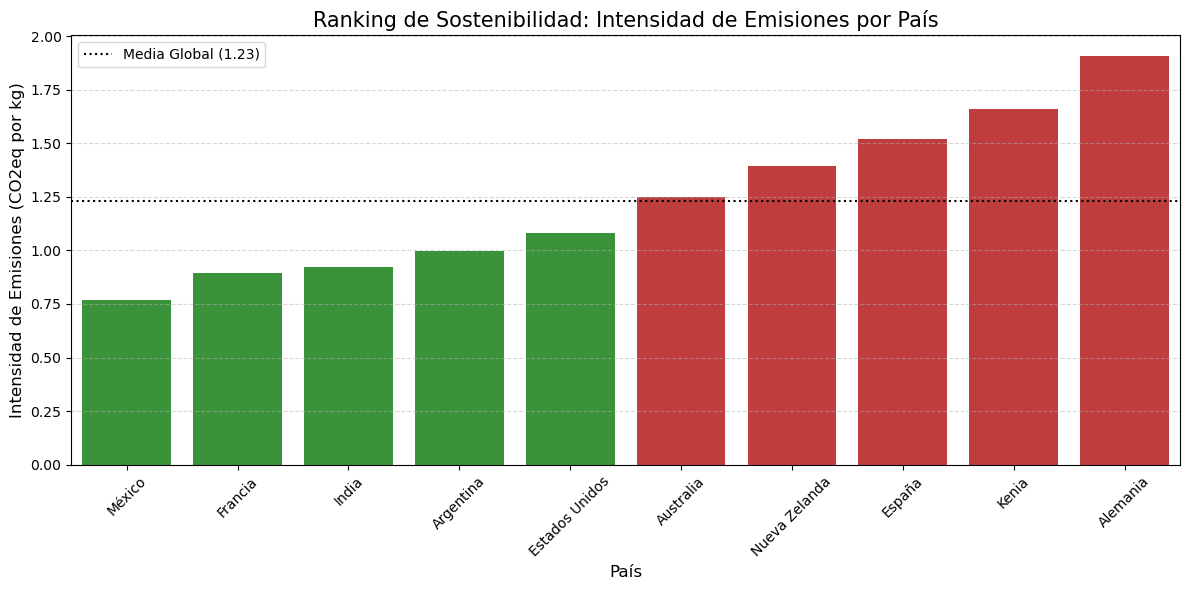

In [ ]:
eficiencia_pais = df_gana.groupby('pais')['intensidad_emisiones'].mean().sort_values().reset_index()

# 2. Seleccionar el Top 5 más limpios y el Top 5 más contaminantes
top_limpios = eficiencia_pais.head(5)
top_contaminantes = eficiencia_pais.tail(5)
ranking_extremos = pd.concat([top_limpios, top_contaminantes])

# 3. Visualización: Gráfico de barras
plt.figure(figsize=(12, 6))
# Colorear verde si están en el top 5 limpio, rojo si están en el top 5 contaminante
colores = ['#2ca02c']*5 + ['#d62728']*5 

sns.barplot(data=ranking_extremos, x='pais', y='intensidad_emisiones', palette=colores)

plt.title('Ranking de Sostenibilidad: Intensidad de Emisiones por País', fontsize=15)
plt.xlabel('País', fontsize=12)
plt.ylabel('Intensidad de Emisiones (CO2eq por kg)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir una línea para marcar el promedio global
media_global = df_gana['intensidad_emisiones'].mean()
plt.axhline(media_global, color='black', linestyle=':', label=f'Media Global ({media_global:.2f})')
plt.legend()
plt.tight_layout()
plt.show()